# Prior Predictive Check

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

## For one simulation calculate the summary statistics from the SFS

In [9]:
# Load the SFS
sfs_path = '/sietch_colab/akapoor/Infer_Demography/experiments_neutral/split_migration_growth/simulations/0/SFS.pkl'
with open(sfs_path, 'rb') as f:
    sfs = pickle.load(f)

In [10]:
sfs

Spectrum([[-- 187258.0 43820.0 ... 0.0 0.0 0.0]
 [187131.0 87485.0 42974.0 ... 0.0 0.0 0.0]
 [43479.0 43148.0 32841.0 ... 0.0 0.0 0.0]
 ...
 [0.0 0.0 0.0 ... 1670.0 1695.0 1012.0]
 [0.0 0.0 0.0 ... 1559.0 2080.0 1987.0]
 [0.0 0.0 0.0 ... 1033.0 2166.0 --]], folded=False, pop_ids=['CO', 'FR'])

In [11]:
sfs.shape

(41, 41)

## Tajima's Pi

There are 20 samples for each -> 40 haplotypes for each. Therefore the dimensions of the SFS will be 41x41 (0 through 40 inclusive).

Let's calculate pi separately for each population

In [14]:
sfs_co = sfs.marginalize([1]) # Sum over axis 1 -> removes axis 1 (FR) and leaves CO

In [15]:
sfs_co

Spectrum([-- 358654.0 171402.0 112279.0 84733.0 67383.0 56360.0 48180.0 42239.0
 37624.0 33823.0 30404.0 28011.0 26109.0 23952.0 22662.0 21317.0 19660.0
 19123.0 18128.0 16689.0 16340.0 15221.0 14648.0 13972.0 13412.0 13110.0
 12353.0 11978.0 11552.0 10959.0 11096.0 10587.0 9955.0 9831.0 9149.0
 9248.0 8894.0 8772.0 8355.0 --], folded=False, pop_ids=['CO'])

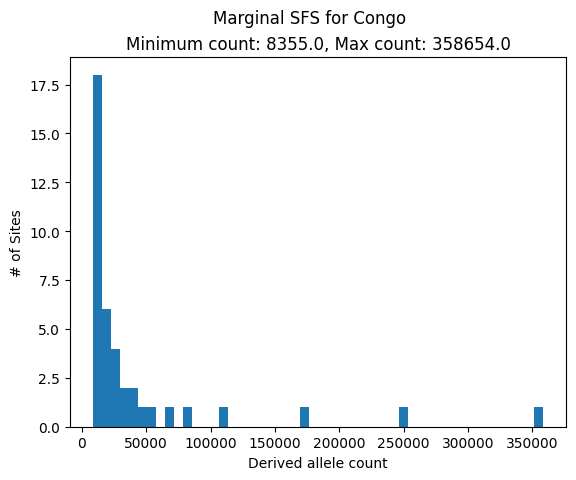

In [21]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(sfs_co, bins= 50)
plt.suptitle("Marginal SFS for Congo")
plt.title(f'Minimum count: {np.min(sfs_co)}, Max count: {np.max(sfs_co)}')
plt.xlabel("Derived allele count")
plt.ylabel("# of Sites")
plt.show()

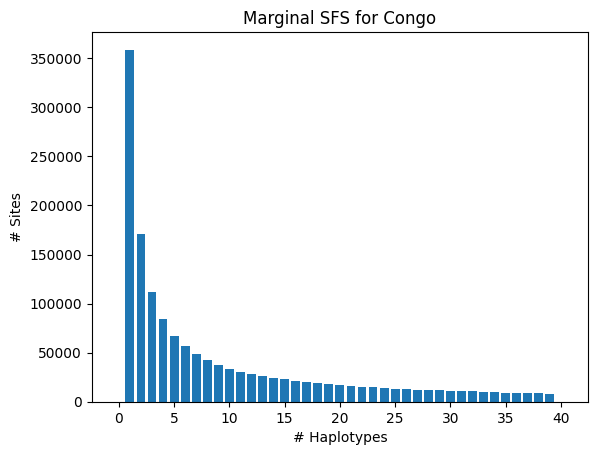

In [23]:
plt.figure()
plt.title("Marginal SFS for Congo")
plt.bar(range(41), np.ma.filled(sfs_co, 0))
plt.xlabel("# Haplotypes")
plt.ylabel("# Sites")
plt.show()


Example interpretation: There are 358,654 sites where exactly 1/40 haplotypes contain the derived allele. There's a lot of rare variation, which we would expect from a neutral process.

In [24]:
sfs_co

Spectrum([-- 358654.0 171402.0 112279.0 84733.0 67383.0 56360.0 48180.0 42239.0
 37624.0 33823.0 30404.0 28011.0 26109.0 23952.0 22662.0 21317.0 19660.0
 19123.0 18128.0 16689.0 16340.0 15221.0 14648.0 13972.0 13412.0 13110.0
 12353.0 11978.0 11552.0 10959.0 11096.0 10587.0 9955.0 9831.0 9149.0
 9248.0 8894.0 8772.0 8355.0 --], folded=False, pop_ids=['CO'])

In [34]:
xi = np.ma.filled(sfs_co, 0)[1:40]   # number of sites at each count i=1..39
xi

array([358654., 171402., 112279.,  84733.,  67383.,  56360.,  48180.,
        42239.,  37624.,  33823.,  30404.,  28011.,  26109.,  23952.,
        22662.,  21317.,  19660.,  19123.,  18128.,  16689.,  16340.,
        15221.,  14648.,  13972.,  13412.,  13110.,  12353.,  11978.,
        11552.,  10959.,  11096.,  10587.,   9955.,   9831.,   9149.,
         9248.,   8894.,   8772.,   8355.])

In [35]:
k = np.arange(1,40)

In [36]:
total_disagreements = np.sum(k * (40 - k) * xi)

In [37]:
total_disagreements

np.float64(264198935.0)

In [39]:
L = 24_000_000

In [40]:
pi = total_disagreements / (780 * L)

In [41]:
pi

np.float64(0.014113190972222222)

In [1]:
import pickle

In [8]:
with open('/sietch_colab/akapoor/Infer_Demography/model_fit/drosophila_three_epoch/dadi/best_fit.pkl', 'rb') as f:
    dadi_drosoph = pickle.load(f)

with open('/sietch_colab/akapoor/Infer_Demography/model_fit/drosophila_three_epoch/moments/best_fit.pkl', 'rb') as f:
    moments_drosoph = pickle.load(f)

In [9]:
with open('/sietch_colab/akapoor/Infer_Demography/model_fit/split_migration_growth/dadi/best_fit.pkl', 'rb') as f:
    dadi_congo_fr = pickle.load(f)

with open('/sietch_colab/akapoor/Infer_Demography/model_fit/split_migration_growth/moments/best_fit.pkl', 'rb') as f:
    moments_congo_fr = pickle.load(f)

In [10]:
dadi_drosoph

{'mode': 'dadi',
 'best_params': {'N_ANC': 3939056.466390248,
  'N_AFR': 906793.9615607176,
  'N_EUR_bottleneck': 164004.43324297346,
  'N_EUR_recover': 39390564.66390248,
  'T_AFR_expansion': 7878112.932780496,
  'T_AFR_EUR_split': 196952.82331951245,
  'T_EUR_expansion': 77778.90365498388},
 'best_ll': 4142542.9993461263,
 'param_order': ['N_ANC',
  'N_AFR',
  'N_EUR_bottleneck',
  'N_EUR_recover',
  'T_AFR_expansion',
  'T_AFR_EUR_split',
  'T_EUR_expansion'],
 'fixed_params': {},
 'theta_hat': 548316.6601215225,
 'N_ANC_implied_from_theta': 3939056.466390248,
 'theta_mode': 'profiled_unit_scaled'}

In [11]:
moments_drosoph

{'mode': 'moments',
 'best_params': {'N_ANC': 3904779.233768534,
  'N_AFR': 908081.0284162434,
  'N_EUR_bottleneck': 161881.11056725643,
  'N_EUR_recover': 39047792.33768534,
  'T_AFR_expansion': 7809558.467537068,
  'T_AFR_EUR_split': 195238.96168842673,
  'T_EUR_expansion': 77614.35179209485},
 'best_ll': 4142239.243480491,
 'param_order': ['N_ANC',
  'N_AFR',
  'N_EUR_bottleneck',
  'N_EUR_recover',
  'T_AFR_expansion',
  'T_AFR_EUR_split',
  'T_EUR_expansion'],
 'fixed_params': {},
 'theta_hat': 543545.2693405799,
 'N_ANC_implied_from_theta': 3904779.233768534,
 'theta_mode': 'profiled_unit_scaled'}

In [12]:
dadi_congo_fr


{'mode': 'dadi',
 'best_params': {'N_ANC': 863547.1090552163,
  'N_CO': 1951730.9362754363,
  'N_FR0': 106115.32057567978,
  'N_FR1': 1457109.150840409,
  'T': 229098.6419742642,
  'm_CO_FR': 8.462999608212064e-10,
  'm_FR_CO': 8.248699266382778e-10},
 'best_ll': 4147994.7845242457,
 'param_order': ['N_ANC', 'N_CO', 'N_FR0', 'N_FR1', 'T', 'm_CO_FR', 'm_FR_CO'],
 'fixed_params': {},
 'theta_hat': 120205.7575804861,
 'N_ANC_implied_from_theta': 863547.1090552163,
 'theta_mode': 'profiled_unit_scaled'}

In [ ]:
4_147_994.7845242457 vs 4_142_542.9993461263